In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

#set general directory with red and green folders inside
s2p_dir = Path("/Users/suthardr/Desktop/akemi")

#load green
#stat file is the ROI dictionary
stat_g = np.load(s2p_dir / 'green/stat.npy', allow_pickle=True)
#ops file contains the metadata including imaging FOV size (Ly, Lx)
ops_g  = np.load(s2p_dir / 'green/ops.npy', allow_pickle=True).item()

#load red
stat_r = np.load(s2p_dir / 'red/stat.npy', allow_pickle=True)
ops_r  = np.load(s2p_dir / 'red/ops.npy', allow_pickle=True).item()

In [3]:
Ly, Lx = ops_g['Ly'], ops_g['Lx'] # Extract image height (Ly) and width (Lx)

In [4]:
#Make empty images for each channel
#dimensions of the FOV (Lx, Ly)
#0 is no ROI in this pixel and 1 is an ROI occupies this pixel
mask_g = np.zeros((Ly, Lx), int)
mask_r = np.zeros((Ly, Lx), int)

In [5]:
#fill your empty mask with the green ROI data
for i, stat in enumerate(stat_g): #go thru each ROI
    y = stat['ypix'][~stat['overlap']] #grab the y and x coords and exclude overlapping pixels between ROIs
    x = stat['xpix'][~stat['overlap']]
    mask_g[y, x] = i + 1 #define these as 1

#same for red channel plz
for j, st in enumerate(stat_r):
    y = st['ypix'][~st['overlap']]
    x = st['xpix'][~st['overlap']]
    mask_r[y, x] = j + 1

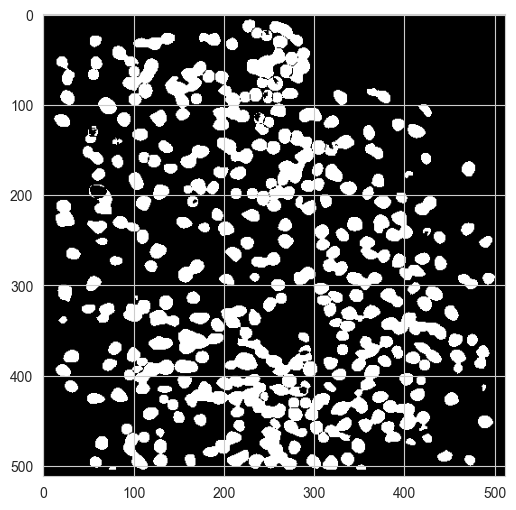

In [15]:
import matplotlib.pyplot as plt

#check your masks look okay
plt.figure(figsize=(6,6))
plt.imshow(mask_g > 0, cmap='gray')
plt.show()

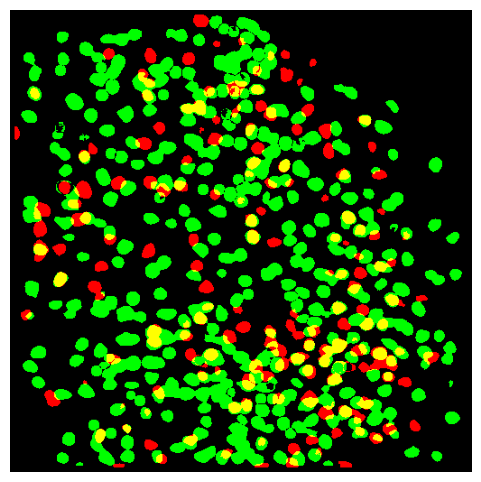

In [16]:
import matplotlib.pyplot as plt
import numpy as np

overlay = np.zeros((Ly, Lx, 3), dtype=float)

# Green channel ROIs
overlay[..., 1] = (mask_g > 0).astype(float)
# Red channel ROIs
overlay[..., 0] = (mask_r > 0).astype(float)

plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.axis('off')
plt.show()

In [18]:
# Find pixels where both green and red ROIs exist
overlap = (mask_g > 0) & (mask_r > 0)
ys, xs = np.where(overlap)

# Track unique overlapping ROI pairs
pairs = set()
for y, x in zip(ys, xs):
    g = mask_g[y, x] - 1   # convert to 0-based green ROI
    r = mask_r[y, x] - 1   # convert to 0-based red ROI
    pairs.add((g, r))

print("Overlapping (green_idx, red_idx) pairs:")
print(sorted(pairs))


Overlapping (green_idx, red_idx) pairs:
[(np.int64(2), np.int64(54)), (np.int64(7), np.int64(51)), (np.int64(7), np.int64(57)), (np.int64(10), np.int64(135)), (np.int64(10), np.int64(141)), (np.int64(10), np.int64(144)), (np.int64(11), np.int64(134)), (np.int64(12), np.int64(141)), (np.int64(14), np.int64(150)), (np.int64(17), np.int64(132)), (np.int64(20), np.int64(32)), (np.int64(21), np.int64(26)), (np.int64(23), np.int64(130)), (np.int64(24), np.int64(130)), (np.int64(25), np.int64(111)), (np.int64(26), np.int64(20)), (np.int64(28), np.int64(73)), (np.int64(29), np.int64(18)), (np.int64(30), np.int64(18)), (np.int64(31), np.int64(18)), (np.int64(32), np.int64(18)), (np.int64(34), np.int64(26)), (np.int64(39), np.int64(18)), (np.int64(41), np.int64(12)), (np.int64(43), np.int64(58)), (np.int64(46), np.int64(57)), (np.int64(53), np.int64(142)), (np.int64(54), np.int64(123)), (np.int64(55), np.int64(118)), (np.int64(56), np.int64(116)), (np.int64(56), np.int64(121)), (np.int64(61), np

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

f = h5py.File(s2p_dir /'green/Fall_cellsOnly.mat', 'r')

/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_61586/3477202982.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Ly = int(f['ops']['Ly'][()])
/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_61586/3477202982.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Lx = int(f['ops']['Lx'][()])


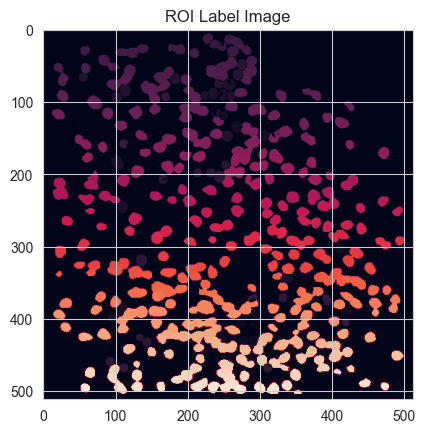

In [31]:
Ly = int(f['ops']['Ly'][()])
Lx = int(f['ops']['Lx'][()])
ncells = f['stat'].shape[0]

im = np.zeros((Ly, Lx))

for n in range(ncells):
    roi = f[f['stat'][n, 0]]

    # pull fields as numpy arrays
    ypix = roi['ypix'][()].astype(int).squeeze()
    xpix = roi['xpix'][()].astype(int).squeeze()
    overlap = roi['overlap'][()].astype(bool).squeeze()

    # exclude suite2p "overlap" pixels
    ypix = ypix[~overlap]
    xpix = xpix[~overlap]

    # label ROI footprint with n+1
    im[ypix, xpix] = n + 1

plt.imshow(im)
plt.title("ROI Label Image")
plt.show()


In [32]:
#alternate option
import h5py
import numpy as np

f_g = h5py.File(s2p_dir /'green/Fall_cellsOnly.mat', 'r')
Ly = int(f_g['ops']['Ly'][()])
Lx = int(f_g['ops']['Lx'][()])
ncells_g = f_g['stat'].shape[0]

mask_g = np.zeros((Ly, Lx), int)

for n in range(ncells_g):
    roi = f_g[f_g['stat'][n, 0]]
    ypix = roi['ypix'][()].squeeze().astype(int)
    xpix = roi['xpix'][()].squeeze().astype(int)
    overlap = roi['overlap'][()].squeeze().astype(bool)

    ypix = ypix[~overlap]
    xpix = xpix[~overlap]
    mask_g[ypix, xpix] = n + 1   # store ROI index+1


f_r = h5py.File(s2p_dir /'red/Fall_cellsOnly.mat', 'r')
ncells_r = f_r['stat'].shape[0]

mask_r = np.zeros((Ly, Lx), int)

for n in range(ncells_r):
    roi = f_r[f_r['stat'][n, 0]]
    ypix = roi['ypix'][()].squeeze().astype(int)
    xpix = roi['xpix'][()].squeeze().astype(int)
    overlap = roi['overlap'][()].squeeze().astype(bool)

    ypix = ypix[~overlap]
    xpix = xpix[~overlap]
    mask_r[ypix, xpix] = n + 1   # store ROI index+1

engram_mask = (mask_g > 0) & (mask_r > 0)


/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_61586/782346687.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Ly = int(f_g['ops']['Ly'][()])
/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_61586/782346687.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Lx = int(f_g['ops']['Lx'][()])


In [38]:
# green ROIs that overlap with any red ROI
green_labels = np.unique(mask_g[engram_mask])
green_ids = green_labels[green_labels > 0] - 1   # 0-based indices

print("Green engram cell indices:", green_ids)

Green engram cell indices: [  2   7  10  11  12  14  20  21  23  24  26  28  29  30  31  32  34  39
  41  46  53  54  55  56  61  74  75  77  82  87  92  93  95  97 100 101
 103 105 106 108 111 114 116 119 126 127 129 133 134 139 141 143 146 151
 152 153 154 155 156 158 162 170 172 177 178 179 182 184 190 193 194 195
 196 203 204 208 217 220 222 223 226 228 229 235 240 245 247 248 249 251
 256 260 261 262 265 266 267 271 272 273 274 275 280 283 285 286 288 292
 293 294 296 297 298 300 301 302 304 308 309 310 311 313 314 316 319 321
 327 331 337 339 340 342 343 344 345 346 347 348 349 351 354 355 362 366
 369 371 372 373 374 375 379 381 382 384 392 393 395 397]


In [39]:
F_green = f_g['F'][()]      # shape: (ncells_g, T)
F_engram_green = F_green[green_ids, :]

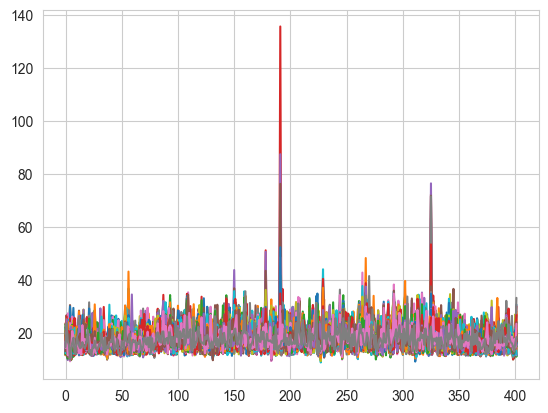

In [41]:
plt.plot(F_engram_green.T)

In [ ]:
#Trying again - Dec 18th, 2025
#Load both files

#Grab good cells only

#Grab mean red image for alignment

